# Логистическая регрессия

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_classification
X,y = make_classification (n_samples=1000,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_classes=2,
                          class_sep=2,
                          random_state=1)

In [3]:
pd.DataFrame(X).head()

,0,1
0,1.863411,0.087646
1,-1.530997,1.901182
2,-0.017224,-2.591112
3,-2.032039,-1.801162
4,4.620555,0.901124


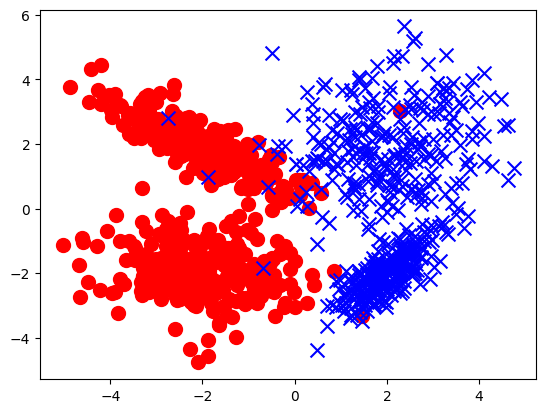

In [4]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.show()

In [5]:
class SGD():
    def __init__(self, alpha=0.5, n_iters=1000):
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters

    def gradient_step(self, b, b_grad):
        return b - self._alpha * b_grad
    
    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        for i in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
        return b
    
    def fit(self, X, y):
        m = X.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(X, y, start_b, self._n_iters)

In [6]:
class LogReg(SGD):
    def sigmoid(self, X, b):        
        return 1. / (1. + np.exp(-X.dot(b)))
    
    def grad_func(self, X, y, b):
        n = X.shape[0]
        grad = 1. / n * X.transpose().dot(self.sigmoid(X, b) - y)
        return grad

    def predict_proba(self, X):
        return self.sigmoid(X, self.b)

    def predict(self, X):
        y_pred = self.predict_proba(X) > 0.5
        return y_pred

In [7]:
logreg = LogReg()

In [8]:
X = np.hstack([np.ones(X.shape[0])[:, np.newaxis], X])

In [9]:
logreg.fit(X, y)
y_pred = logreg.predict(X)

In [10]:
from sklearn.metrics import accuracy_score, f1_score
ac = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
print(f'accuracy = {ac:.2f} F1-score = {f1:.2f}')

accuracy = 0.98 F1-score = 0.98


In [13]:
y_pred_proba = logreg.predict_proba(X)

In [14]:
xx, yy = np.meshgrid(
    np.arange(X.min(axis=0)[1]-1, X.max(axis=0)[1]+1, 0.01), 
    np.arange(X.min(axis=0)[2]-1, X.max(axis=0)[2]+1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))
XX = np.array([(1, *xx) for xx in XX])

In [15]:
Z = logreg.predict_proba(XX)
Z = Z.reshape(xx.shape)

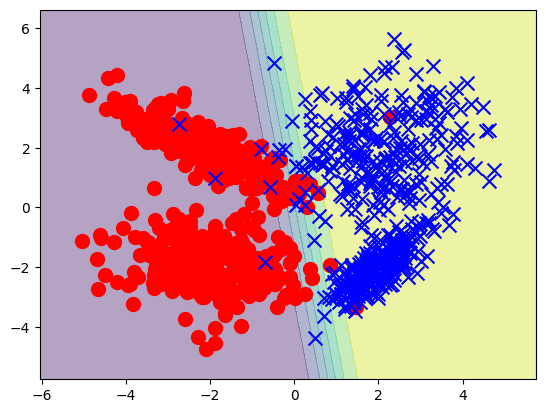

In [16]:
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 1][y==0], X[:, 2][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 1][y==1], X[:, 2][y==1], marker="x", c='b', s=100)

In [18]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [20]:
model.fit(X, y)
y_pred_lr = model.predict(X)

---
## Задание 1: Результаты библиотечной модели — численно и графически

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       499
           1       0.97      0.98      0.98       501

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



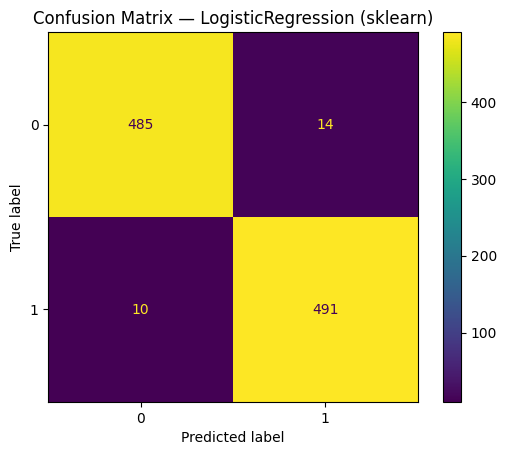

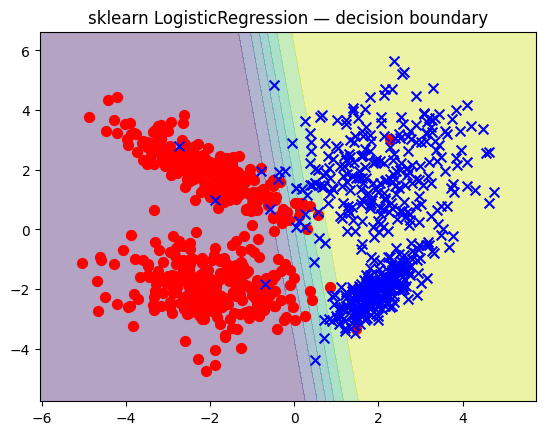

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print(classification_report(y, y_pred_lr))

ConfusionMatrixDisplay(confusion_matrix(y, y_pred_lr)).plot()
plt.title("Confusion Matrix — LogisticRegression (sklearn)")
plt.show()

# Граница решения библиотечной модели
Z_lr = model.predict_proba(XX)[:, 1].reshape(xx.shape)
plt.contourf(xx, yy, Z_lr, alpha=0.4)
plt.scatter(X[:, 1][y==0], X[:, 2][y==0], marker="o", c='r', s=50)
plt.scatter(X[:, 1][y==1], X[:, 2][y==1], marker="x", c='b', s=50)
plt.title("sklearn LogisticRegression — decision boundary")
plt.show()

## Задание 2: Разные скорости обучения — поиск расхождения

In [ ]:
for alpha in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]:
    m = LogReg(alpha=alpha)
    m.fit(X, y)
    yp = m.predict(X)
    acc = accuracy_score(y, yp)
    # NaN в весах — признак расхождения
    status = "РАСХОДИТСЯ" if np.any(np.isnan(m.b)) else "OK"
    print(f"alpha={alpha:>5}  accuracy={acc:.3f}  [{status}]")

alpha= 0.01  accuracy=0.973  [OK]
alpha=  0.1  accuracy=0.977  [OK]
alpha=  0.5  accuracy=0.976  [OK]
alpha=  1.0  accuracy=0.976  [OK]
alpha=  5.0  accuracy=0.976  [OK]
alpha= 10.0  accuracy=0.976  [OK]


## Задание 3: Фиктивный столбец единиц внутри класса

In [ ]:
class LogRegBias(LogReg):
    """Логистическая регрессия — фиктивный столбец добавляется внутри."""

    def _add_bias(self, X):
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def fit(self, X, y):
        super().fit(self._add_bias(X), y)

    def predict_proba(self, X):
        return super().predict_proba(self._add_bias(X))

    # predict НЕ переопределяем — он унаследуется от LogReg и вызовет этот predict_proba


# Используем чистые признаки (без столбца единиц)
X_raw, y_raw = make_classification(n_samples=1000, n_features=2,
                                   n_informative=2, n_redundant=0,
                                   n_classes=2, class_sep=2, random_state=1)
m3 = LogRegBias()
m3.fit(X_raw, y_raw)
print("accuracy:", round(accuracy_score(y_raw, m3.predict(X_raw)), 4))

accuracy: 0.976


## Задание 4: Влияние параметра class_sep

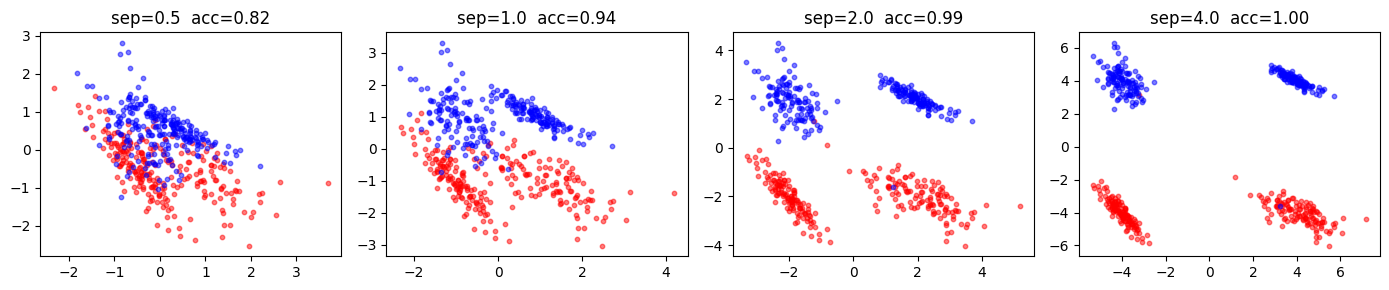

In [ ]:
seps = [0.5, 1.0, 2.0, 4.0]
fig, axes = plt.subplots(1, len(seps), figsize=(14, 3))

for ax, sep in zip(axes, seps):
    Xs, ys = make_classification(n_samples=500, n_features=2,
                                 n_informative=2, n_redundant=0,
                                 class_sep=sep, random_state=1)
    m = LogRegBias().fit(Xs, ys) or LogRegBias()
    # fit возвращает None — пересоздаём
    m = LogRegBias()
    m.fit(Xs, ys)
    acc = accuracy_score(ys, m.predict(Xs))

    ax.scatter(Xs[:, 0][ys==0], Xs[:, 1][ys==0], s=10, c='r', alpha=0.5)
    ax.scatter(Xs[:, 0][ys==1], Xs[:, 1][ys==1], s=10, c='b', alpha=0.5)
    ax.set_title(f"sep={sep}  acc={acc:.2f}")

plt.tight_layout()
plt.show()
# Вывод: чем больше class_sep, тем лучше разделены классы и выше accuracy.

## Задание 5: Датасет с большим числом признаков

In [48]:
X5, y5 = make_classification(n_samples=1000, n_features=20,
                             n_informative=10, n_redundant=5,
                             n_classes=2, random_state=0)
m5 = LogRegBias()
m5.fit(X5, y5)
print("20 признаков -> accuracy:", round(accuracy_score(y5, m5.predict(X5)), 4))

# Для сравнения — sklearn
from sklearn.linear_model import LogisticRegression as LR
print("sklearn     -> accuracy:", round(LR().fit(X5, y5).score(X5, y5), 4))

20 признаков -> accuracy: 0.662
sklearn     -> accuracy: 0.732


## Задание 6: Множественная классификация — "один против всех"

OvR accuracy: 0.971
sklearn OvR:  0.971


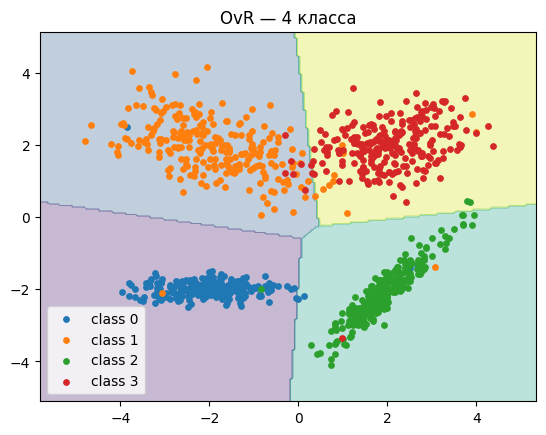

In [52]:
X6, y6 = make_classification(n_samples=1000, n_features=2,
                             n_informative=2, n_redundant=0,
                             n_classes=4, n_clusters_per_class=1,
                             class_sep=2, random_state=0)

class OvRLogReg:
    """Алгоритм 'один против всех' на основе LogRegBias."""
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.models_ = {}
        for c in self.classes_:
            m = LogRegBias()
            m.fit(X, (y == c).astype(int))  # бинарная задача: класс c vs остальные
            self.models_[c] = m
        return self

    def predict_proba(self, X):
        # матрица вероятностей n_samples x n_classes
        return np.column_stack([self.models_[c].predict_proba(X)
                                for c in self.classes_])

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


ovr = OvRLogReg().fit(X6, y6)
print("OvR accuracy:", round(accuracy_score(y6, ovr.predict(X6)), 4))

print("sklearn OvR: ", round(LR().fit(X6, y6).score(X6, y6), 4))

# Визуализация границ
xx6, yy6 = np.meshgrid(np.arange(X6[:,0].min()-1, X6[:,0].max()+1, 0.05),
                        np.arange(X6[:,1].min()-1, X6[:,1].max()+1, 0.05))
grid = np.c_[xx6.ravel(), yy6.ravel()]
Z6 = ovr.predict(grid).reshape(xx6.shape)
plt.contourf(xx6, yy6, Z6, alpha=0.3)
for c in np.unique(y6):
    plt.scatter(X6[y6==c, 0], X6[y6==c, 1], s=15, label=f"class {c}")
plt.legend(); plt.title("OvR — 4 класса"); plt.show()

## Задание 7: Вероятности принадлежности классам (sklearn)

   P(class=0)  P(class=1)  predicted  true
0      0.0037      0.9963          1     1
1      0.9862      0.0138          0     0
2      0.7931      0.2069          0     0
3      0.9993      0.0007          0     0
4      0.0000      1.0000          1     1
5      0.0072      0.9928          1     1
6      0.0000      1.0000          1     1
7      0.9398      0.0602          0     0
8      0.9999      0.0001          0     0
9      0.9948      0.0052          0     0


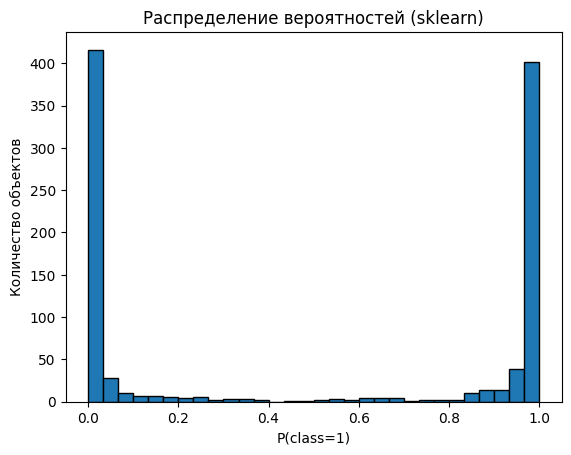

In [53]:
# predict_proba возвращает [P(класс=0), P(класс=1)] для каждого объекта
proba = model.predict_proba(X)  # model обучен на исходном X с bias-столбцом
df_proba = pd.DataFrame(proba, columns=["P(class=0)", "P(class=1)"])
df_proba["predicted"] = model.predict(X)
df_proba["true"] = y
print(df_proba.head(10).round(4))

# Гистограмма уверенности модели
plt.hist(proba[:, 1], bins=30, edgecolor='k')
plt.xlabel("P(class=1)")
plt.ylabel("Количество объектов")
plt.title("Распределение вероятностей (sklearn)")
plt.show()